In [1]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors as colors
import torch

In [2]:
from torchvision.transforms.functional import hflip,vflip

In [ ]:
print(torch.__version__)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

In [4]:
import os
import time                   
import sys
import argparse 

In [5]:
import matplotlib as mpl
mpl.rcParams["font.size"] = 18
mpl.rcParams['axes.titlesize'] = 18

In [6]:
remove_im_mean = lambda data : data - data.mean(dim=(1,2,3),keepdims=True )
def im_set_corr(set1, set2, remove_mean=True):
    '''
    im_set: tensor of size N,C,H, W
    '''

    if len(set1.shape) != 4 or len(set2.shape) != 4 :
        raise ValueError('Input shape error')
    if remove_mean: 
        set1 = remove_im_mean(set1)
        set2 = remove_im_mean(set2)

    norms1 = set1.norm(dim=(2,3), keepdim=True).norm(dim=1, keepdim=True)
    norms1[norms1 == 0 ] = .001 # to avoid dividing by 0 for blank images 
    norms2 = set2.norm(dim=(2,3), keepdim=True).norm(dim=1, keepdim=True)
    norms2[norms2 == 0 ] = .001 # to avoid dividing by 0 for blank images 
    
    return torch.matmul(((set1/norms1).flatten(start_dim=1)),
             (set2/norms2).flatten(start_dim=1).T)


In [22]:
ntrain=100_000     # size of the dataset used for training: eg. 1000, 10000, 100000
epoch=147          # epoch of optimisation  (eg. 0, 50, 100, 147 or 150)
rootdir = "./results/train_"+str(ntrain)+"_noaugatall_A-generated-"+str(epoch)
gan_samples_A = np.load(rootdir + "/gan-samples_10000.npy")

In [8]:
gan_samples_A =gan_samples_A[:1000].astype(np.float32)

In [9]:
gan_samples_A= np.expand_dims(gan_samples_A, axis=(1,))
gan_samples_A = torch.asarray(gan_samples_A,device="cpu")

In [11]:
rootdir = "./results/train_"+str(ntrain)+"_noaugatall_B-generated-"+str(epoch)
gan_samples_B = np.load(rootdir + "/gan-samples_10000.npy")

In [12]:
gan_samples_B =gan_samples_B[:1000].astype(np.float32)
gan_samples_B= np.expand_dims(gan_samples_B, axis=(1,))
gan_samples_B = torch.asarray(gan_samples_B,device="cpu")

In [14]:
# cosine similarity model A vs model B
sims = im_set_corr ( (gan_samples_A) , (gan_samples_B) ).diag().cpu().flatten()
bins = np.linspace(0.75,1.05 ,50)

In [ ]:
data = torch.load('../datasets/sdss_train_no_repeats_64x64.pt')
K = data.shape[2]
train = data[0:ntrain]  # train for model A

In [16]:
# H, V and HV flip versions of the training images
train_hflip = hflip(train)
train_vflip = vflip(train)
train_vhflip = vflip(train_hflip)

In [17]:
train_all = torch.cat((train,train_hflip,train_vflip,train_vhflip))

In [18]:
train_all = train_all.to("cpu")

In [20]:
# cosine similarity model A vs training
corrs = im_set_corr((gan_samples_A), (train_all))
values, indices = corrs.max(dim = 1)

In [26]:
SMALL_SIZE = 34
MEDIUM_SIZE = 36
BIGGER_SIZE = 38

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

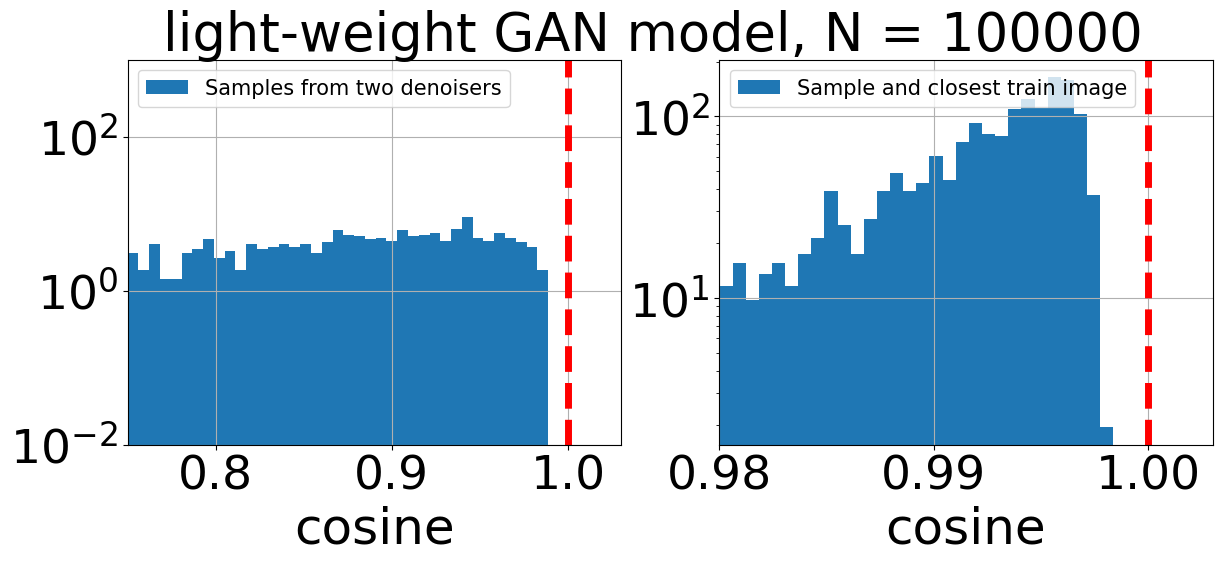

In [27]:
fig,ax = plt.subplots(1,2,figsize = (7*2,5))
fig.suptitle(f"light-weight GAN model, N = {ntrain}");
ax[0].hist(sims, bins = np.linspace(0.75,1.05 ,50), label='Samples from two denoisers', alpha = 1, density=True);
ax[0].legend(fontsize = 15);
ax[0].set_xlim(0.75,1.03)
ax[0].set_ylim(1e-2,1e3)
ax[0].axvline(x=1.0,c='r',lw=5,ls="--")
ax[0].set_yscale("log")
ax[0].set_xlabel("cosine")
ax[0].grid()


ax[1].hist(values , bins = np.linspace(0.98,1.01,50), label = 'Sample and closest train image', alpha = 1.0, density=True)
ax[1].set_xlim(0.98,1.003)
ax[1].legend(fontsize = 15);
ax[1].set_yscale("log")
ax[1].axvline(x=1.0,c='r',lw=5,ls="--")
ax[1].set_xlabel("cosine")
ax[1].grid()


plt.savefig("gan-cosine-AB_ATrain.pdf",bbox_inches='tight')